<a href="https://colab.research.google.com/github/Samarbal/Big-Data-Analysis/blob/main/Big_Data_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LAB 2 EXERCISE

Samar M. Balousha

2320222601


In [9]:
# import labraries
import pandas as pd
import numpy as np
import time
import os

In [10]:
import pyarrow as pa
import pyarrow.parquet as pq
from pyarrow import dataset as ds

In [36]:
import shutil

# Remove old wrong partitions (if any)
for d in ['sales_by_date', 'sales_by_region', 'sales_by_category']:
    if os.path.exists(d):
        shutil.rmtree(d)

 # Ex 1  File Format Comparison

based on :

 1. Write time: How long it takes to save the DataFrame.
 2. Read time: How long it takes to load the DataFrame.
 3. File size: The size of the saved file.
 4. Query performance:  Time taken for a filter and aggregation operation



In [11]:
# data size
n_rows = 2000000

In [12]:
files_data = pd.DataFrame({
 'id': range(n_rows),
 'timestamp': pd.date_range('2023-01-01', periods=n_rows, freq='1s'),
 'category': np.random.choice(['A', 'B', 'C', 'D', 'E'], n_rows),
 'value1': np.random.randn(n_rows),
 'value2': np.random.randn(n_rows),
 'value3': np.random.uniform(0, 100, n_rows),
 'text': [f'Transaction_{i}' for i in range(n_rows)]
})

In [13]:
# size of the data in memory
mem_size = files_data.memory_usage().sum() / 1024**2
print(f"Memory size in RAM {mem_size:.2f} MB")

Memory size in RAM 106.81 MB


In [14]:
file_formats = ['csv', 'json', 'parquet', 'feather', 'pickle']
results = []

In [15]:
# Comparison
for format in file_formats:
    filename = f'temp_data.{format}'

    # measure write time
    start_time = time.time()
    # if csv format
    if format == 'csv':
        files_data.to_csv(filename, index=False)
     # if json format
    elif format == 'json':
        files_data.to_json(filename, orient='records', lines=True)
     # if parquet format
    elif format == 'parquet':
      files_data.to_parquet(filename, index=False)
     # if feather format
    elif format == 'feather':
      files_data.to_feather(filename)
    # if pickle format
    elif format == 'pickle':
      files_data.to_pickle(filename)
      # write time
    write_time = time.time() - start_time

    # ----------------------------------------
    # measure file size
    file_size_mb = os.path.getsize(filename)/ (1024 * 1024)
    # ----------------------------------
    # compression ratio
    compression_ratio = mem_size / file_size_mb if file_size_mb > 0 else 0
    #-------------------------------
    # measure read time
    start_time = time.time()
    if format == 'csv':
        df_read = pd.read_csv(filename)
    elif format == 'json':
        df_read = pd.read_json(filename, orient='records', lines=True)
    elif format == 'parquet':
        df_read = pd.read_parquet(filename)
    elif format == 'feather':
        df_read = pd.read_feather(filename)
    elif format == 'pickle':
        df_read = pd.read_pickle(filename)
    read_time = time.time() - start_time

    #----------------------------------------------
    # Query performance (filter + aggregation)
    start_time = time.time()
    filter_aggregate=  df_read[df_read['category'] == 'A']['value1'].mean()
    query_time = time.time() - start_time
    #----------------------------------------
    # store results
    results.append({
        'Format': format.capitalize(),
        'Write Time (s)': write_time,
        'Size (MB)': file_size_mb,
        'Read Time (s)': read_time,
        'Query Time (s)': query_time,
        'Comparsion Ratio': compression_ratio })


comparison_df = pd.DataFrame(results)

In [16]:
print(f'Orignal data size : {mem_size}')
print(".................")
display(comparison_df)

Orignal data size : 106.81164932250977
.................


,Format,Write Time (s),Size (MB),Read Time (s),Query Time (s),Comparsion Ratio
0,Csv,19.939871,202.813771,4.308426,0.227183,0.526649
1,Json,7.086589,288.879899,9.627389,0.193572,0.369744
2,Parquet,1.212760,78.361028,1.755183,0.299832,1.363071
3,Feather,0.879462,90.112932,2.239784,0.521165,1.185309
4,Pickle,1.515061,121.025637,0.434831,0.231963,0.882554


#### Quick Analysis after the comparasion

1. Fastest Write Time: Feather
2. fastest Read Time: Pickle
3. Smallest File Size: Parquet
4. Best Query Performance: Pickle
5. Parquet gives best compression (1.37x smaller than memory size )
6. Binray formats (Feather, Parquet, Pickle) significantly out performed text-based formats (CSV, JSON) in all metrics, making them more suitable for Big Data applications.




# EX 2 : Partition Strategy

Exercise 2: Partition Strategy

Given a sales dataset with 'date' column

 Implement partition by:

 1. Date (daily partitions)
 2. Region (geographic partitions)
 3. Product category

 Compare:
 - Number of partitions
 - Partition size distribution
- Query performance for different scenarios

In [37]:
# Creating data for one million sales transactions
np.random.seed(42)
n_rows = 1000000

dates = pd.date_range('2023-01-01', periods=100, freq='D')
regions = ['North', 'South', 'East', 'West', 'Central']

categories = ['Electronics', 'Clothing', 'Home', 'Toys', 'Cosmatics', 'Furniture', 'Sport']
units_sold = np.random.randint(1, 20, size=n_rows)
unit_price = np.random.uniform(10, 100, size=n_rows)
total_sales = units_sold * unit_price

sales_df = pd.DataFrame({
    'date': np.random.choice(dates, n_rows),
    'region': np.random.choice(regions, n_rows),
    'category': np.random.choice(categories, n_rows),
    'units_sold': units_sold,
    'unit_price': unit_price,
    'total_sales': total_sales

})
sales_df['date'] = pd.to_datetime(sales_df['date']).dt.date

print("Dataset shape:", sales_df.shape)
print(sales_df.head())
print("\nUnique dates:", sales_df['date'].nunique())
print("Unique regions:", sales_df['region'].nunique())
print("Unique categories:", sales_df['category'].nunique())

Dataset shape: (1000000, 6)
         date   region   category  units_sold  unit_price  total_sales
0  2023-01-28    South  Cosmatics           7   92.597767   648.184366
1  2023-02-09    North   Clothing          15   23.646165   354.692477
2  2023-02-06    North       Home          11   47.115668   518.272349
3  2023-02-07  Central   Clothing           8   93.435988   747.487901
4  2023-01-03    North  Furniture           7   85.110821   595.775750

Unique dates: 100
Unique regions: 5
Unique categories: 7


In [38]:
# partition implementation using Parquet ( because it support the partition effisiontly )

# 1. partition by date
print("Partition by Date : ")
start = time.time()
sales_df.to_parquet('sales_by_date', partition_cols=['date'])
finish_time = time.time() - start
print(f'Done in {finish_time:.2f} sec  ')
print("............................................")

# 2. partition by region
print("Partition by region:  ")
start = time.time()
sales_df.to_parquet('sales_by_region', partition_cols=['region'])
finish_time = time.time() - start
print(f'Done in {finish_time:.2f} sec  ')
print("............................................")

# 3. partition by category
print("Partition by category :")
start = time.time()
sales_df.to_parquet('sales_by_category', partition_cols=['category'])
finish_time = time.time() - start
print(f'Done in {finish_time:.2f} sec  ')



Partition by Date : 
Done in 0.83 sec  
............................................
Partition by region:  
Done in 0.36 sec  
............................................
Partition by category :
Done in 0.37 sec  


In [39]:
import glob

def get_partition_stats(partition_dir):
    """
    Return:
      - num_partitions: how many distinct partition values
      - sizes: list of file sizes in bytes for each partition
      - rows: list of row counts per partition (optional)
    """
    # Pattern: partition_dir/partition_value/*.parquet
    parquet_files = glob.glob(os.path.join(partition_dir, '*', '*.parquet'))
    sizes = []
    rows = []
    for f in parquet_files:
        sizes.append(os.path.getsize(f))
        # Read just the row count from metadata (fast, doesn't load data)
        import pyarrow.parquet as pq
        pf = pq.ParquetFile(f)
        rows.append(pf.metadata.num_rows)
    return len(parquet_files), sizes, rows

# Compute stats for each strategy
for name, path in [('Date', 'sales_by_date'),
                   ('Region', 'sales_by_region'),
                   ('Category', 'sales_by_category')]:
    n, sizes, rows = get_partition_stats(path)
    print(f"\n=== {name} partitions ===")
    print(f"Number of partitions: {n}")
    print(f"Min size: {min(sizes):,} bytes")
    print(f"Max size: {max(sizes):,} bytes")
    print(f"Mean size: {np.mean(sizes):,.0f} bytes")
    print("--------------------------------------------")
    print(f"Rows per partition: min={min(rows)}, max={max(rows)}, mean={np.mean(rows):.0f}")


=== Date partitions ===
Number of partitions: 100
Min size: 230,479 bytes
Max size: 239,268 bytes
Mean size: 234,578 bytes
--------------------------------------------
Rows per partition: min=9794, max=10237, mean=10000

=== Region partitions ===
Number of partitions: 5
Min size: 4,268,269 bytes
Max size: 4,283,437 bytes
Mean size: 4,277,190 bytes
--------------------------------------------
Rows per partition: min=199580, max=200297, mean=200000

=== Category partitions ===
Number of partitions: 7
Min size: 3,057,600 bytes
Max size: 3,074,463 bytes
Mean size: 3,068,346 bytes
--------------------------------------------
Rows per partition: min=142347, max=143150, mean=142857


**query preformance**

In [40]:
# query preformance
# Baseline: single Parquet file (no partitions)
baseline_file = 'sales_baseline.parquet'
sales_df.to_parquet(baseline_file, index=False)

In [41]:
# make sure all are exist in the folder
print("baseline:", os.path.exists('sales_baseline.parquet'))
print("date partition:", os.path.exists('sales_by_date'))
print("region partition:", os.path.exists('sales_by_region'))
print("category partition:", os.path.exists('sales_by_category'))

baseline: True
date partition: True
region partition: True
category partition: True


In [42]:
# helper functions
def read_partition(dataset_dir, partition_col, partition_value):
    """
it only reads the section that equals partition_value in the partition_col column.    """
    dataset = ds.dataset(dataset_dir, format='parquet', partitioning='hive')
    # condition :  partition_col = partition_value
    filter_expr = ds.field(partition_col) == partition_value
    table = dataset.to_table(filter=filter_expr)
    return table.to_pandas()

def full_scan(dataset_dir):
    """
    Scan all data
    """
    dataset = ds.dataset(dataset_dir, format='parquet', partitioning='hive')
    table = dataset.to_table()
    return table.to_pandas()

In [43]:

if 'sales_df' not in globals():
    sales_df = pd.read_parquet('sales_baseline.parquet')

test_date = sales_df['date'].iloc[0]          # أول تاريخ في البيانات
test_region = sales_df['region'].iloc[0]      # أول منطقة
test_category = sales_df['category'].iloc[0]  # أول فئة

print(f"query : select all where date =  {test_date}")
print(f"query: select * where region =  {test_region}")
print(f" query: delect * where category=  {test_category}")

query : select all where date =  2023-01-28
query: select * where region =  South
 query: delect * where category=  Cosmatics


In [44]:
#  Baseline queries : on the data set without partition
results = []  # لتخزين النتائج

# Filter on date
start = time.time()
df_baseline_date = sales_df[sales_df['date'] == test_date]
t_baseline_date = time.time() - start
results.append(("Baseline", "Filter on date", t_baseline_date))
print(f"Filter on date (baseline): {t_baseline_date:.4f} sec")

# filter on region
start = time.time()
df_baseline_region = sales_df[sales_df['region'] == test_region]
t_baseline_region = time.time() - start
results.append(("Baseline", "Filter on region", t_baseline_region))
print(f"Filter on region (baseline): {t_baseline_region:.4f} sec")

# filter on category
start = time.time()
df_baseline_category = sales_df[sales_df['category'] == test_category ]
t_baseline_category = time.time() - start
results.append(("Baseline", "Filter on Category ", t_baseline_category))
print(f"Filter on category  (baseline): {t_baseline_category:.4f} sec")

Filter on date (baseline): 0.0691 sec
Filter on region (baseline): 0.1280 sec
Filter on category  (baseline): 0.0948 sec


In [45]:
#  Date partition
dataset_dir = 'sales_by_date'

# Query with filtering on the partition column (date)
start = time.time()
df_date_pruned = read_partition(dataset_dir, 'date', "test_date")
t_date_pruned = time.time() - start
results.append(("Date partition", "Pruned filter on date", t_date_pruned))
print(f"Date partition (pruned): {t_date_pruned:.4f} sec")

# full scan for sales by date
start = time.time()
df_date_full = full_scan(dataset_dir)
t_date_full = time.time() - start
results.append(("Date partition", "Full scan all partitions", t_date_full))
print(f"Date partition (full scan): {t_date_full:.4f} sec")

Date partition (pruned): 0.0090 sec
Date partition (full scan): 0.5699 sec


In [46]:
# Region partition
dataset_dir = 'sales_by_region'

# Query with filtering on the partition column (region )
start = time.time()
df_region_pruned = read_partition(dataset_dir, 'region', test_region)
t_region_pruned = time.time() - start
results.append(("Region partition", "Pruned filter on region", t_region_pruned))
print(f"Region partition (pruned): {t_region_pruned:.4f} sec")

# full scan for sales by regin
start = time.time()
df_region_full = full_scan(dataset_dir)
t_region_full = time.time() - start
results.append(("Region partition", "Full scan all partitions", t_region_full))
print(f"Region partition (full scan): {t_region_full:.4f} sec")

Region partition (pruned): 0.0243 sec
Region partition (full scan): 0.0966 sec


In [47]:
# Category partition
dataset_dir = 'sales_by_category'

start = time.time()
df_cat_pruned = read_partition(dataset_dir, 'category', test_category)
t_cat_pruned = time.time() - start
results.append(("Category partition", "Pruned filter on category", t_cat_pruned))
print(f"Category partition (pruned): {t_cat_pruned:.4f} sec")

# full scan for sales by category
start = time.time()
df_cat_full = full_scan(dataset_dir)
t_cat_full = time.time() - start
results.append(("Category partition", "Full scan all partitions", t_cat_full))
print(f"Category partition (full scan): {t_cat_full:.4f} sec")

Category partition (pruned): 0.0179 sec
Category partition (full scan): 0.1056 sec



=== Query preformance Table ===
          Strategy                Query Type  Time (seconds)
          Baseline            Filter on date        0.069098
          Baseline          Filter on region        0.128031
          Baseline       Filter on Category         0.094771
    Date partition     Pruned filter on date        0.009026
    Date partition  Full scan all partitions        0.569941
  Region partition   Pruned filter on region        0.024292
  Region partition  Full scan all partitions        0.096590
Category partition Pruned filter on category        0.017895
Category partition  Full scan all partitions        0.105592


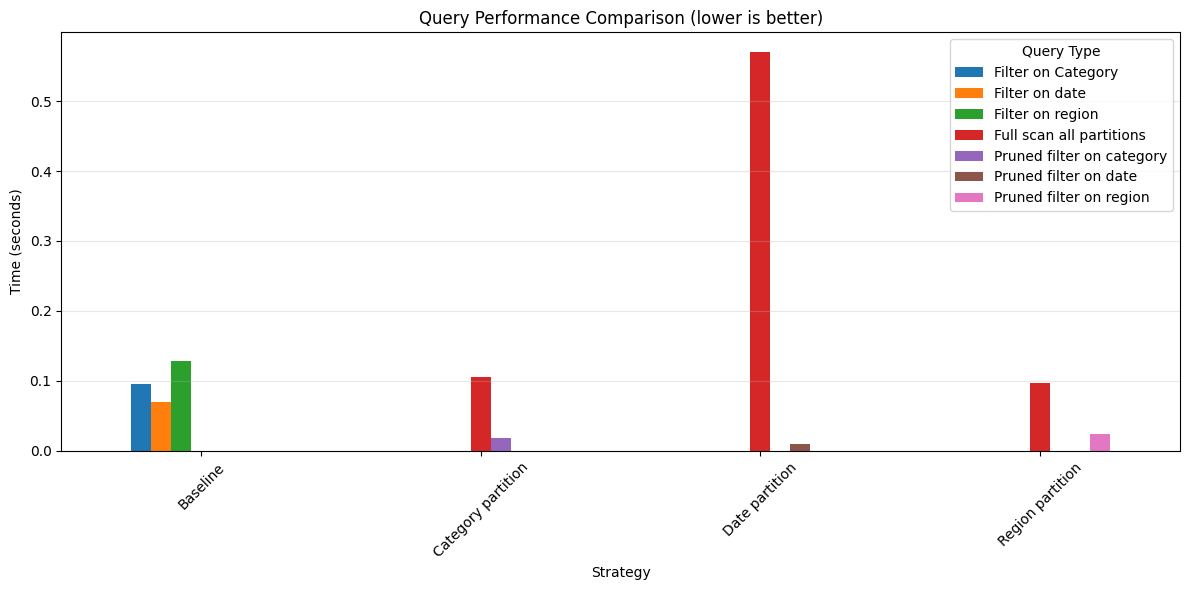

In [49]:
# Store the results in dataframe and show it
results_df = pd.DataFrame(results, columns=['Strategy', 'Query Type', 'Time (seconds)'])
print("\n=== Query preformance Table ===")
print(results_df.to_string(index=False))

# رسم بياني
import matplotlib.pyplot as plt

pivot = results_df.pivot(index='Strategy', columns='Query Type', values='Time (seconds)')
pivot.plot(kind='bar', figsize=(12,6))
plt.ylabel('Time (seconds)')
plt.title('Query Performance Comparison (lower is better)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# EX 3  : Big Data Storage & Cost Planning


In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [1]:
# calcuslate storage analysis
def calculate_storage_cost(raw_gb, replication, compression_ratio):
    compressed = raw_gb / compression_ratio    #   الحجم بعذ الضغط
    final_storage = compressed * replication   # الحجم النهائي بعد المضاعفو النسخ
    monthly_cost = final_storage * 0.023   #   #  التكلفة الشهرية  dollar
    yearly_cost = monthly_cost * 12    # التكلفة السنوية
    return final_storage, monthly_cost, yearly_cost

In [3]:
# Network analysis
def network_time(compressed_gb, bandwidth_mbps=100):
    data_megabits = compressed_gb * 8 * 1024   # bamdwidth in mega bits
    seconds = data_megabits / bandwidth_mbps    #  حجم البيانات / السرعة  = الوقت بالثواني
    return seconds, seconds/3600, seconds/(3600*24)    # return the time in sec, hours and days

In [5]:
# Test Senario
raw = 10000  # GB
repl = 3
comp = 4
print ("--Senario Results --")
storage, month_cost, year_cost = calculate_storage_cost(raw, repl, comp)
compressed = raw / comp

print(f"Raw Data: {raw} GB")
print(f"Compression Ratio: {comp}:1")
print(f"Compressed Size: {compressed:.2f} GB")
print(f"Final Storage (3x Replication): {storage:.2f} GB")
print(f"Monthly Cost (S3): ${month_cost:.2f}")
print(f"Yearly Cost: ${year_cost:.2f}")

sec, hrs, days = network_time(compressed)
print(f"Transfer Time (Compressed) @ 100 Mbps: {sec:.0f} sec = {hrs:.2f} hrs = {days:.2f} days")



--Senario Results --
Raw Data: 10000 GB
Compression Ratio: 4:1
Compressed Size: 2500.00 GB
Final Storage (3x Replication): 7500.00 GB
Monthly Cost (S3): $172.50
Yearly Cost: $2070.00
Transfer Time (Compressed) @ 100 Mbps: 204800 sec = 56.89 hrs = 2.37 days


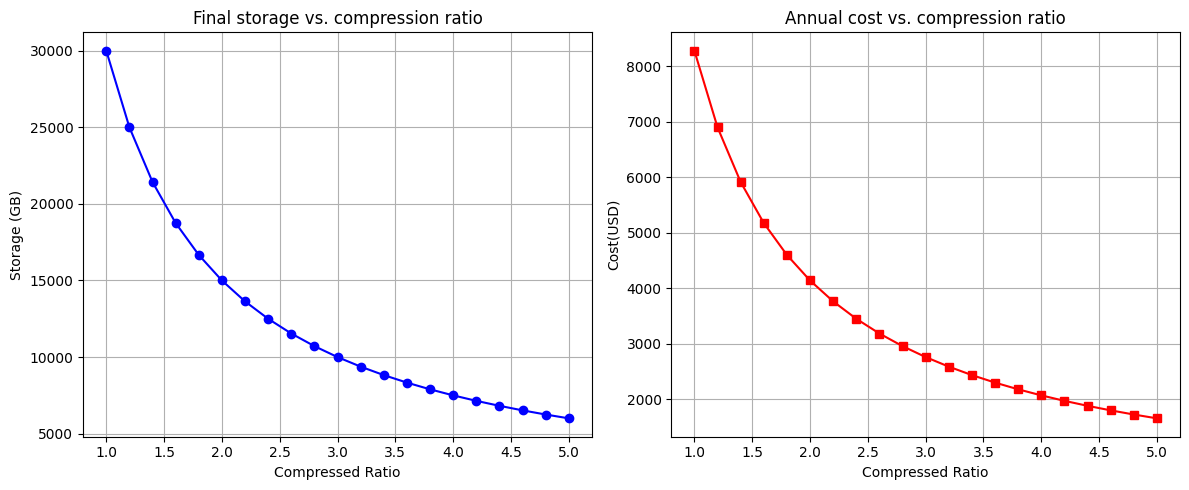

In [8]:
# visualze the results :
ratios = np.arange(1, 5.1 , 0.2)
storages = []
costs = []
for r in ratios:
    s, _, y = calculate_storage_cost(raw, repl, r)
    storages.append(s)
    costs.append(y)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(ratios, storages, 'b-o')
plt.title("Final storage vs. compression ratio")
plt.xlabel("Compressed Ratio")
plt.ylabel("Storage (GB)")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(ratios, costs, 'r-s')
plt.title("Annual cost vs. compression ratio")
plt.xlabel("Compressed Ratio")
plt.ylabel("Cost(USD)")
plt.grid(True)

plt.tight_layout()
plt.show()